In [1]:
import os
import urllib.request
import zipfile
from functools import partial

import pandas as pd
import xarray as xr
import pynncml

from pynncml.datasets.dataset import LinkDataset
from pynncml.datasets.gauge_data import PointSensor
from pynncml.datasets import PointSet
import numpy as np
import netCDF4 as nc

from pynncml.datasets.xarray_processing import xarray2link, LinkSelection

from scipy.interpolate import interp1d

import sys
from pathlib import Path

from load_link_set import *

C:\Users\gabir\Documents\OpenMesh_pynncml\PyNNcml\pynncml\model_zoo\model_common.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import os
from pathlib import Path

# find the OpenMesh-1 root automatically
root = Path.cwd()

while root.name != "OpenMesh_pynncml":
    root = root.parent

os.chdir(root)
print("Working directory set to:", root)


Working directory set to: c:\Users\gabir\Documents\OpenMesh_pynncml


In [3]:
import sys
from pathlib import Path

# Add the notebooks directory to Python path
# Since Cell 1 changes cwd to project root, we need the relative path from there
notebooks_dir = Path.cwd() / 'src' / 'analysis' / 'pynncml_experiments' / 'notebooks'
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

Import files

In [4]:
# ============================================
# PATH CONFIGURATION
# ============================================
from pathlib import Path

# Choose user
USER = "gabir"  # Options: "user" or "dror"

# Base path (relative to project root - Cell 1 sets working directory to project root)
BASE_PATH = Path("dataset")

# All paths built from base path
linkspath = str(BASE_PATH / "links" / "ds_openmesh.nc")
metapath = str(BASE_PATH / "links" / "links_metadata.csv")
# Note: pws_opensense_sample_jan.nc is in dataset root, not in weather stations folder
gaugespath = str(BASE_PATH / "weather stations" / "pws_opensense_sample_jan.nc")
gaugemetapath = str(BASE_PATH / "weather stations" / "pws_metadata.csv")

# Load data
with xr.open_dataset(linkspath) as ds:
    pass
links_meta = pd.read_csv(metapath)




1. Gauge data to Point Sensors

In [5]:
# CREATE POINT SENSORS
ps = guage_to_linkset(gaugemetapath, gaugespath)


CONVERTING NETCDF GROUPS TO XARRAY DICT

  ✓ KNYNEWYO1472: 4402 records
  ✓ KNYNEWYO1659: 4606 records
  ✓ KNYNEWYO1288: 3743 records
  ✓ KNYNEWYO1896: 4606 records
  ✓ KNYNEWYO1921: 4605 records
  ✓ KNYNEWYO1931: 4606 records
  ✓ KNYNEWYO1313: 4604 records
  ✓ KNYNEWYO1918: 4604 records
  ✓ KNYNEWYO1298: 4606 records
  ✓ KNYNEWYO1388: 4599 records
  ✓ KNYNEWYO1606: 4606 records
  ✓ KNYNEWYO1943: 290 records
  ✓ KNYNEWYO1348: 4606 records
  ✓ KNYNEWYO1942: 373 records
  ✓ KNYNEWYO1238: 4544 records
  ✓ KNYNEWYO1401: 4587 records
  ✓ KNYNEWYO1824: 4605 records
  ✓ KNYNEWYO343: 4606 records
  ✓ KNYNEWYO1626: 4604 records
  ✓ KNYNEWYO1747: 1171 records
  ✓ KNYNEWYO589: 4605 records
  ✓ KNYNEWYO1591: 4606 records
  ✓ KNYNEWYO638: 3958 records
  ✓ KNYNEWYO1796: 4606 records
  ✓ KNYNEWYO1805: 4534 records
  ✓ KNYNEWYO1622: 4606 records
  ✓ KNYNEWYO1024: 1506 records
  ✓ KNYNEWYO1533: 4580 records
  ✓ KNYNEWYO1651: 1534 records
  ✓ KNYNEWYO1120: 4606 records
  ✓ KNYNEWYO1900: 4605 records
  


Plotting data for 37 gauges from PointSet...



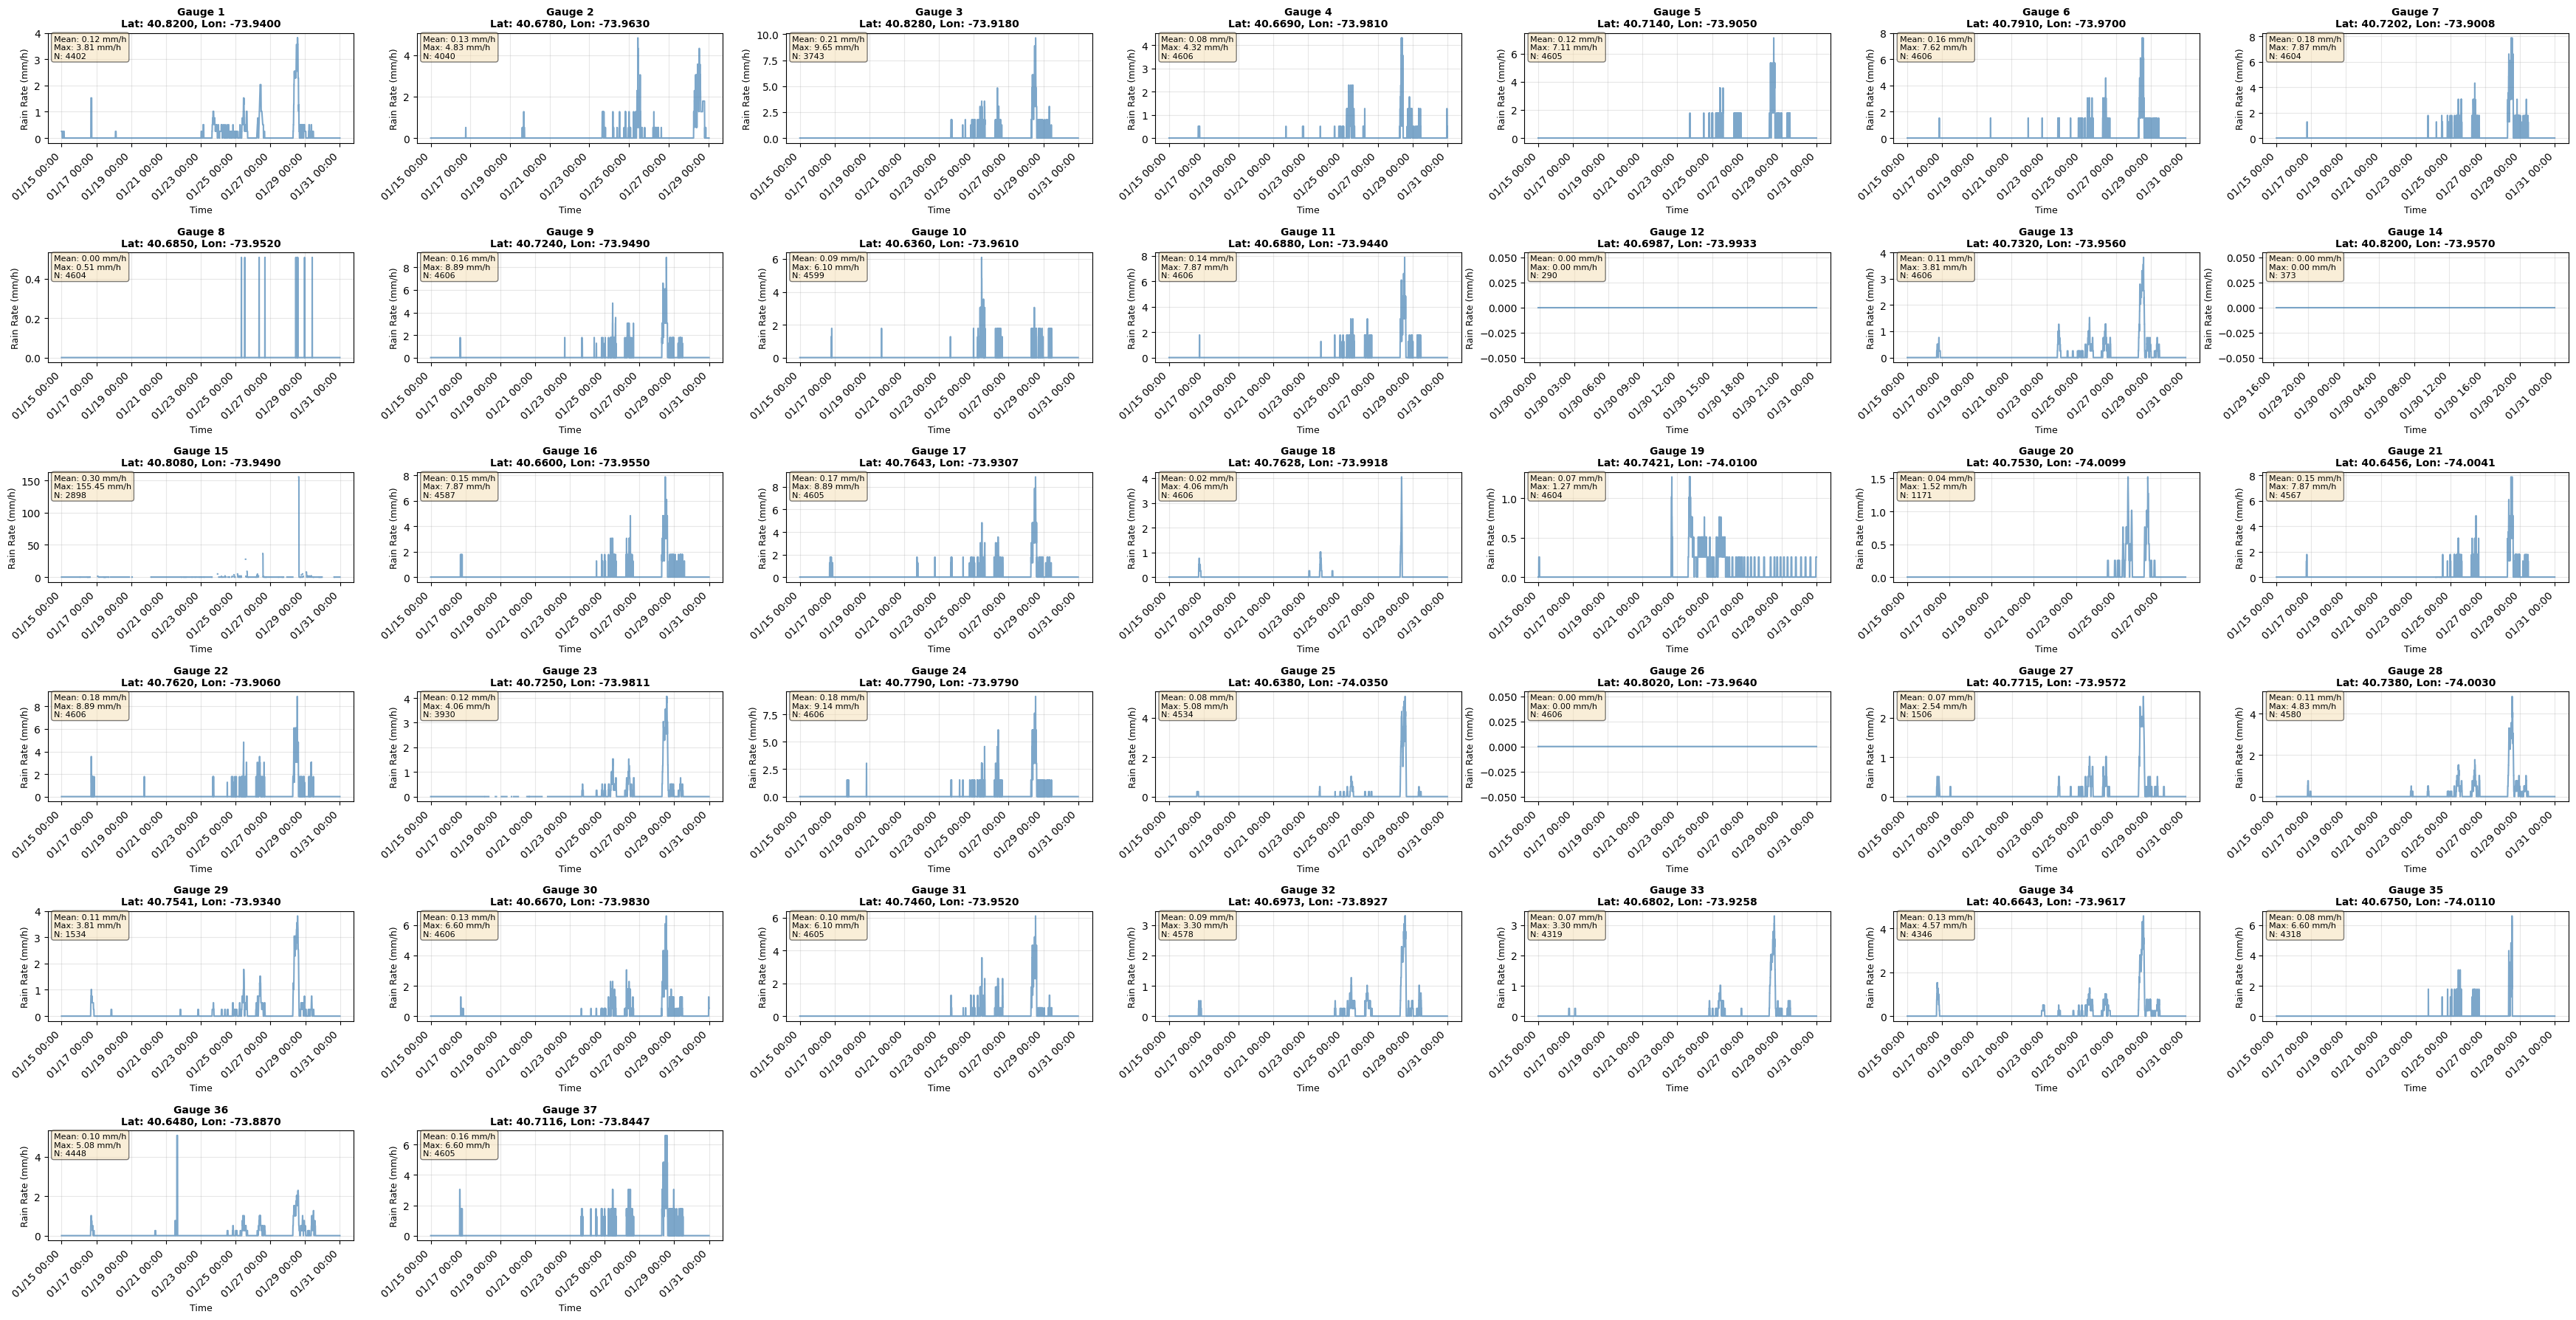

✓ Plotted 37 gauges from PointSet


In [8]:
# ============================================
# PLOT EACH GAUGE IN POINTSET (ps) OVER TIME
# ============================================
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import numpy as np

# Get number of gauges in PointSet
n_gauges = len(ps.point_set)
print(f"\nPlotting data for {n_gauges} gauges from PointSet...\n")

# Determine subplot layout (aim for roughly square grid)
n_cols = int(np.ceil(np.sqrt(n_gauges)))
n_rows = int(np.ceil(n_gauges / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
# Flatten axes array for easier indexing
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes] if not isinstance(axes, list) else axes

# Plot each gauge in the PointSet
for idx, gauge in enumerate(ps.point_set):
    ax = axes[idx]
    
    # Get time and data arrays
    time_array = gauge.time_array
    data_array = gauge.data_array
    
    # Convert time to datetime if it's Unix timestamp
    if np.issubdtype(time_array.dtype, np.number):
        # Assume Unix timestamp (seconds since epoch)
        time_datetime = pd.to_datetime(time_array, unit='s')
    else:
        time_datetime = pd.to_datetime(time_array)
    
    # Plot the data
    ax.plot(time_datetime, data_array, linewidth=1.5, alpha=0.7, color='steelblue')
    ax.set_title(f'Gauge {idx+1}\nLat: {gauge.lat:.4f}, Lon: {gauge.lon:.4f}', 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Time', fontsize=9)
    ax.set_ylabel('Rain Rate (mm/h)', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis dates
    ax.xaxis.set_major_formatter(DateFormatter('%m/%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Add statistics text
    valid_data = data_array[~np.isnan(data_array)]
    if len(valid_data) > 0:
        stats_text = f'Mean: {np.nanmean(data_array):.2f} mm/h\nMax: {np.nanmax(data_array):.2f} mm/h\nN: {len(valid_data)}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax.text(0.5, 0.5, 'No valid data', transform=ax.transAxes,
                fontsize=10, ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

# Hide unused subplots
for idx in range(n_gauges, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print(f"✓ Plotted {n_gauges} gauges from PointSet")


2. From xarray to LinkSet

In [6]:
# Create the LinkSet from 24/01 until 31/01
link_set = patched_xarray2link_with_gauges(ds, ps, max_distance=5000, change2min_max=True, time_slice=True, start='2024-01-24', end='2024-01-31')

print(f"✅ Created LinkSet with {len(link_set)} sublinks")

Processing sublinks:   0%|          | 0/3 [00:00<?, ?it/s]c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data


Processing Summary:
  ✅ Valid links created: 100
  ⚠️  Skipped (missing coordinates): 0
  ⚠️  Skipped (no RSL data): 125
  📊 Total processed: 225

✅ Created LinkSet with 100 sublinks


### Rain detection for short periods on high frequency sublinks

Get High frequency sublinks:

In [7]:
highfreq = [
    link
    for link in link_set.link_list
    if link.meta_data.frequency > 68.0
]

highfreqID = []
for i in range(0,len(link_set)):
    if link_set.get_link(i).meta_data.frequency >= 68:
        highfreqID.append(i)

highfreqID

[0, 2, 7, 16, 19, 21, 28, 30, 31, 33, 35, 39, 43, 74, 88, 98]

In [8]:
HF_set = keep_links(link_set, highfreqID, True)

Pick sublink #0 for rain analysis

In [9]:
linkmm = HF_set.get_link(0)

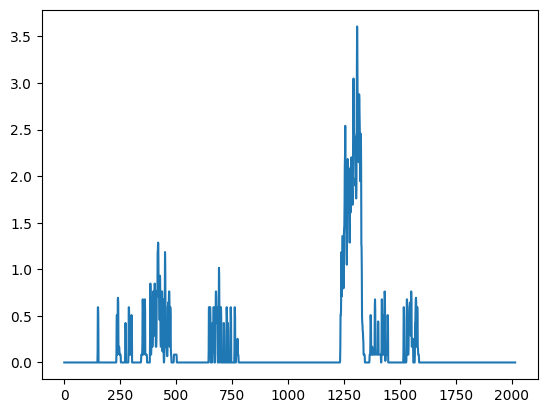

In [10]:
plt.plot(linkmm.gauge_ref[0].data_array)

### Rain detection for every high-frequency sublink
### std threshold = 0.65

link frequency: 68.04


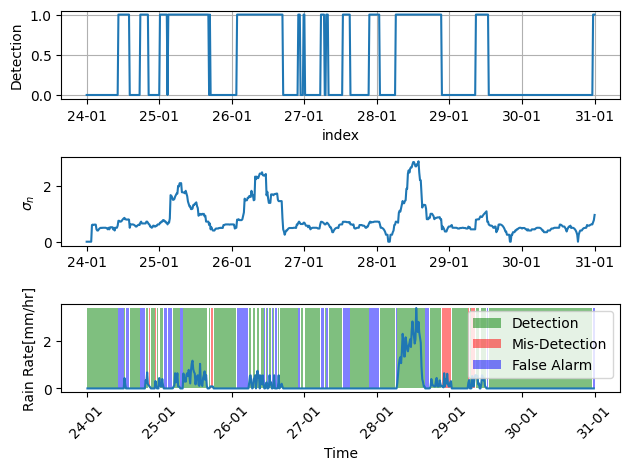

Accuracy:  77.4%
Precision: 55.8%
Recall:    82.9%
link frequency: 68.04


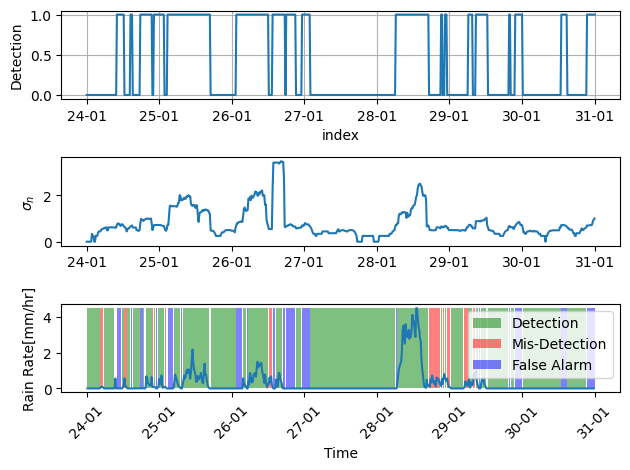

Accuracy:  75.8%
Precision: 62.8%
Recall:    76.5%
link frequency: 68.04


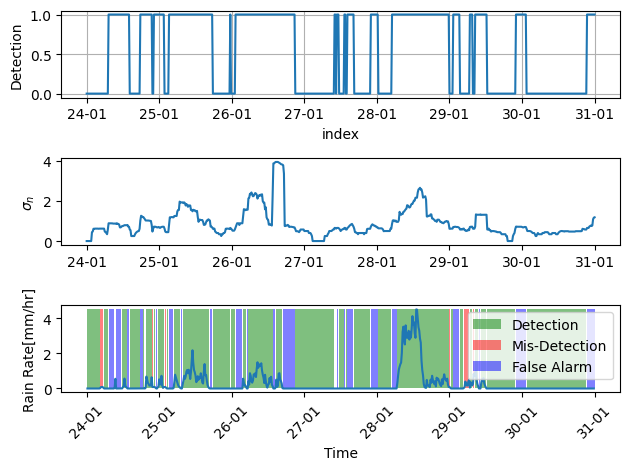

Accuracy:  75.5%
Precision: 60.1%
Recall:    90.2%
link frequency: 68.04


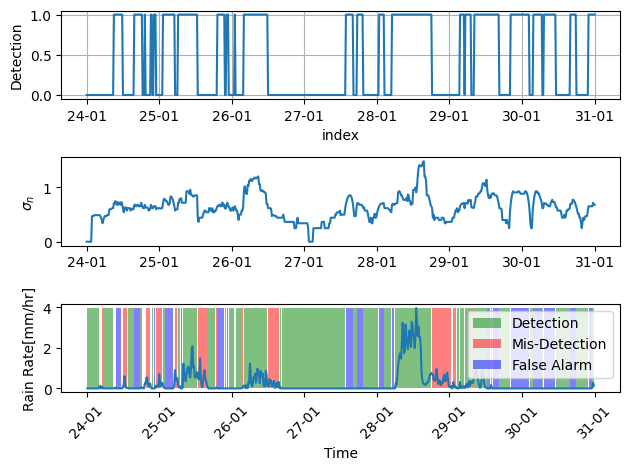

Accuracy:  60.8%
Precision: 49.8%
Recall:    59.4%
link frequency: 69.12


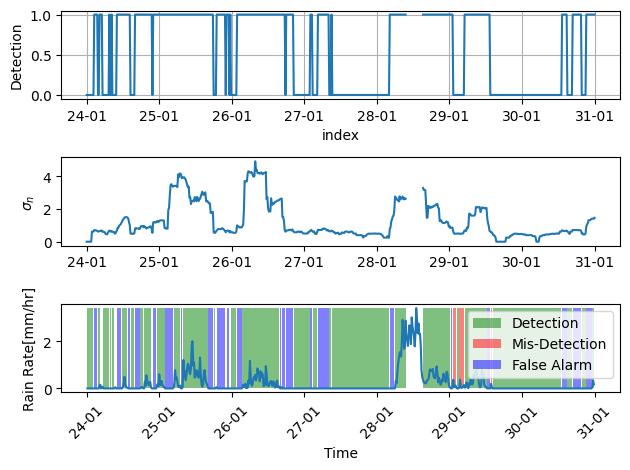

Accuracy:  71.5%
Precision: 59.2%
Recall:    92.4%
link frequency: 69.12


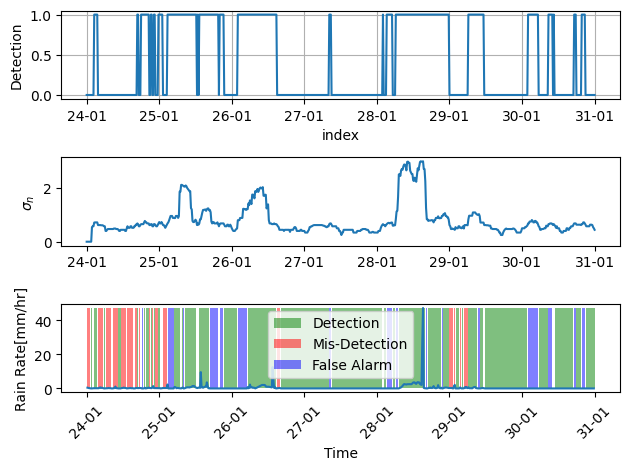

Accuracy:  71.8%
Precision: 64.9%
Recall:    67.8%
link frequency: 68.04


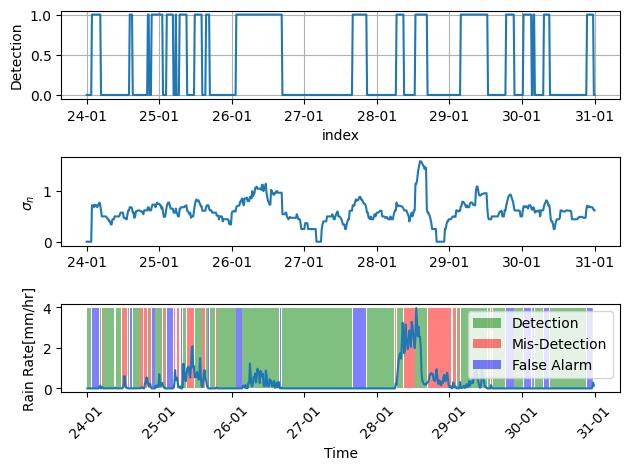

Accuracy:  68.2%
Precision: 59.8%
Recall:    57.5%
link frequency: 68.04


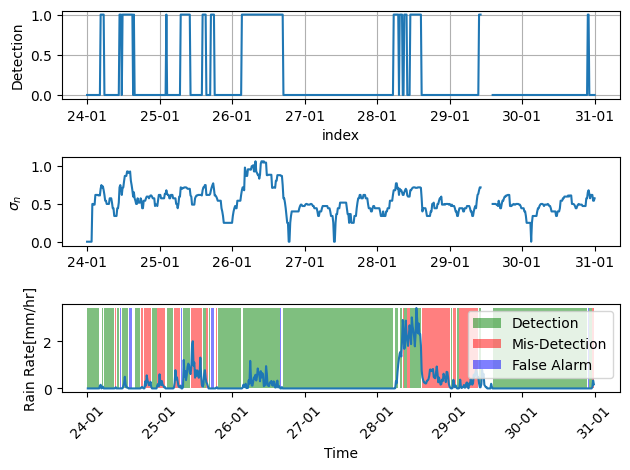

Accuracy:  72.7%
Precision: 79.6%
Recall:    44.0%
link frequency: 68.04


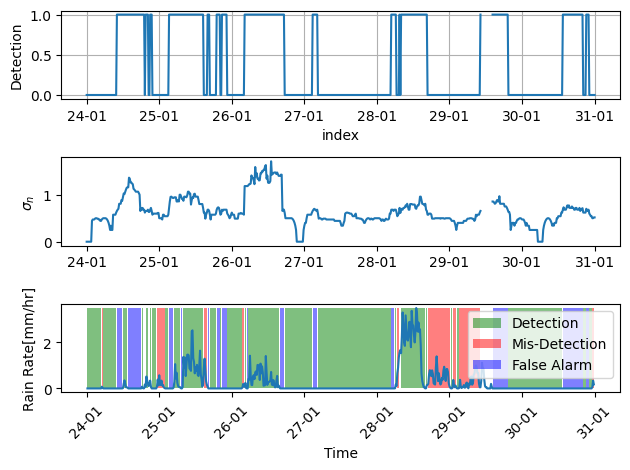

Accuracy:  64.8%
Precision: 52.9%
Recall:    58.7%
link frequency: 68.04


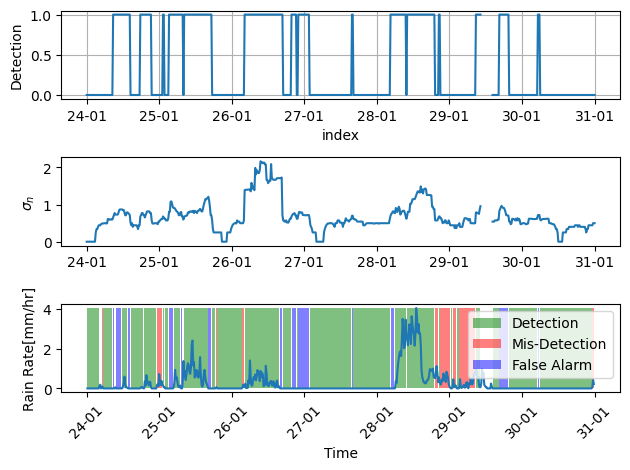

Accuracy:  75.6%
Precision: 69.7%
Recall:    71.7%
link frequency: 68.04


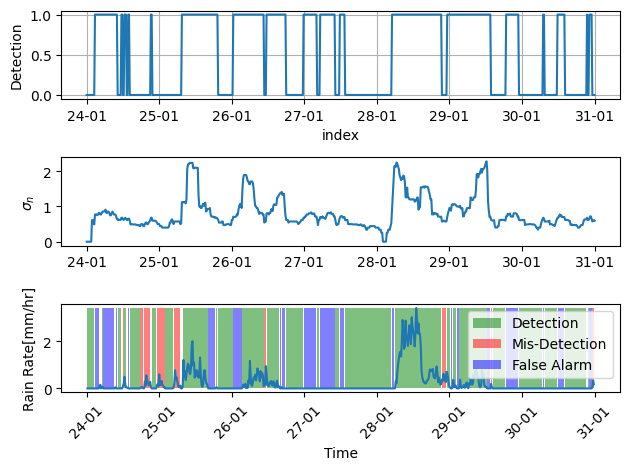

Accuracy:  69.2%
Precision: 57.4%
Recall:    79.5%
link frequency: 68.04


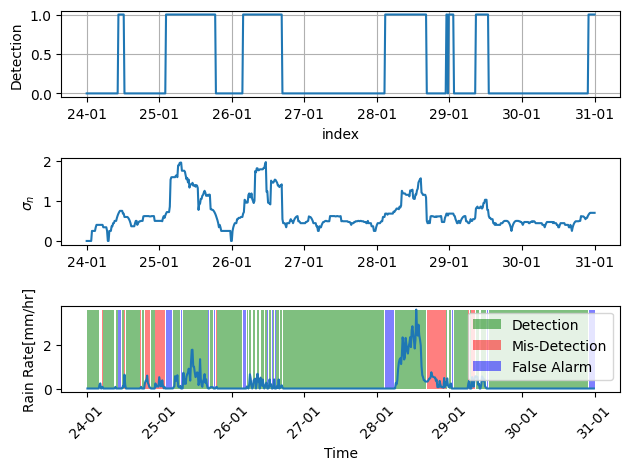

Accuracy:  79.5%
Precision: 68.8%
Recall:    68.2%
link frequency: 68.04


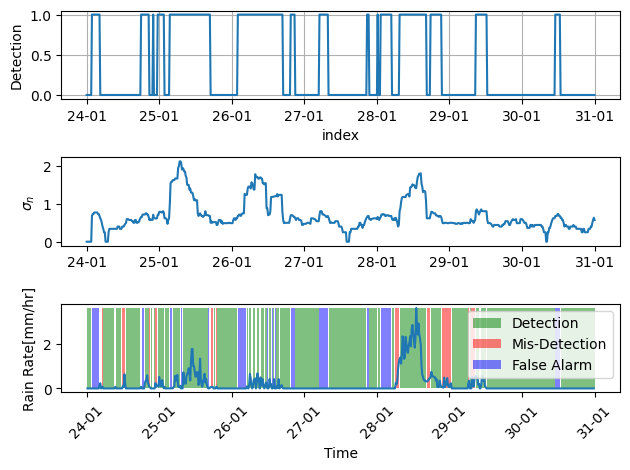

Accuracy:  77.6%
Precision: 63.3%
Recall:    74.7%
link frequency: 68.04


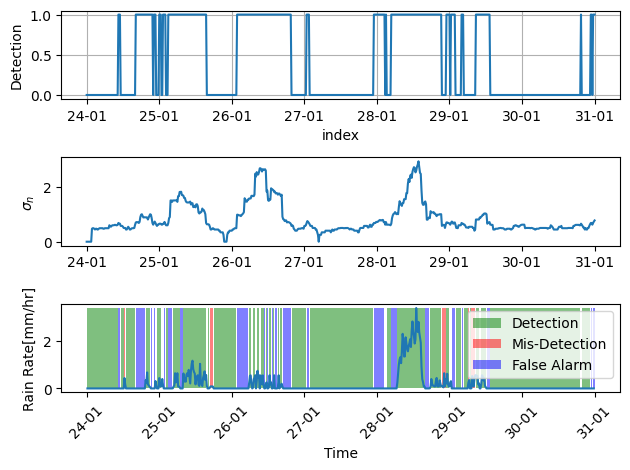

Accuracy:  76.7%
Precision: 54.6%
Recall:    85.6%
link frequency: 68.04


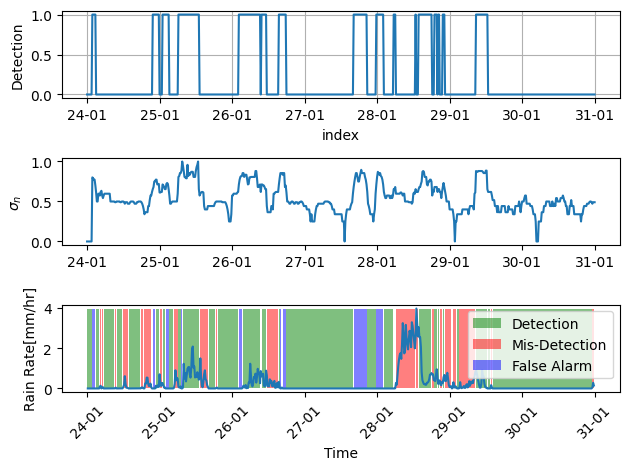

Accuracy:  68.9%
Precision: 65.7%
Recall:    43.3%
link frequency: 68.04


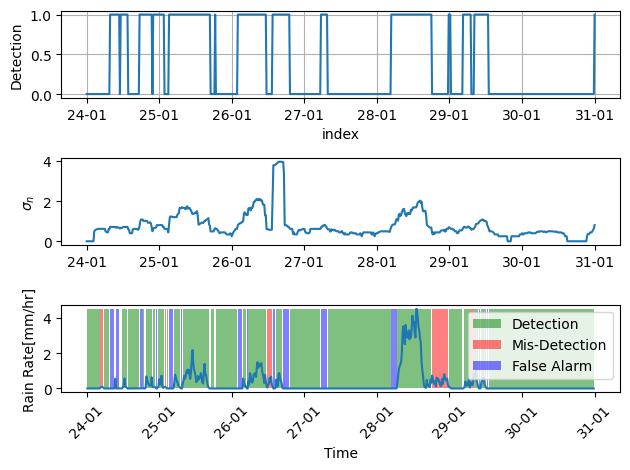

Accuracy:  81.9%
Precision: 71.3%
Recall:    81.6%


In [11]:
for i in range(0,len(HF_set)):
    print(f'link frequency: {HF_set.get_link(i).meta_data.frequency}')
    classification_plot(HF_set.get_link(i),0.65,15)

Rain Estimation

In [ ]:
# @title Rain Estimation Hyper-parameters
wa_factor = 1  # @param{"type": "number"}
r_min = 0.6  # @param{"type": "number"}
dynamic_baseline_window_size = 20  # @param{"type": "integer"}
statistics_window_size = 15
statistics_wet_dry_threshold = 0.65


In [12]:
tsc = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, r_min,
                                                         statistics_window_size, statistics_wet_dry_threshold,
                                                         wa_factor=wa_factor)
os_baseline = pnc.scm.rain_estimation.one_step_dynamic_baseline(pnc.scm.power_law.PowerLawType.MAX, r_min,
                                                                dynamic_baseline_window_size, 1)

att = linkmm.attenuation()
rain_ts, wd, ts_baseline_res = tsc(att,
                                linkmm.meta_data)
rain_os, os_baseline_res = os_baseline(att,
                                    linkmm.meta_data)

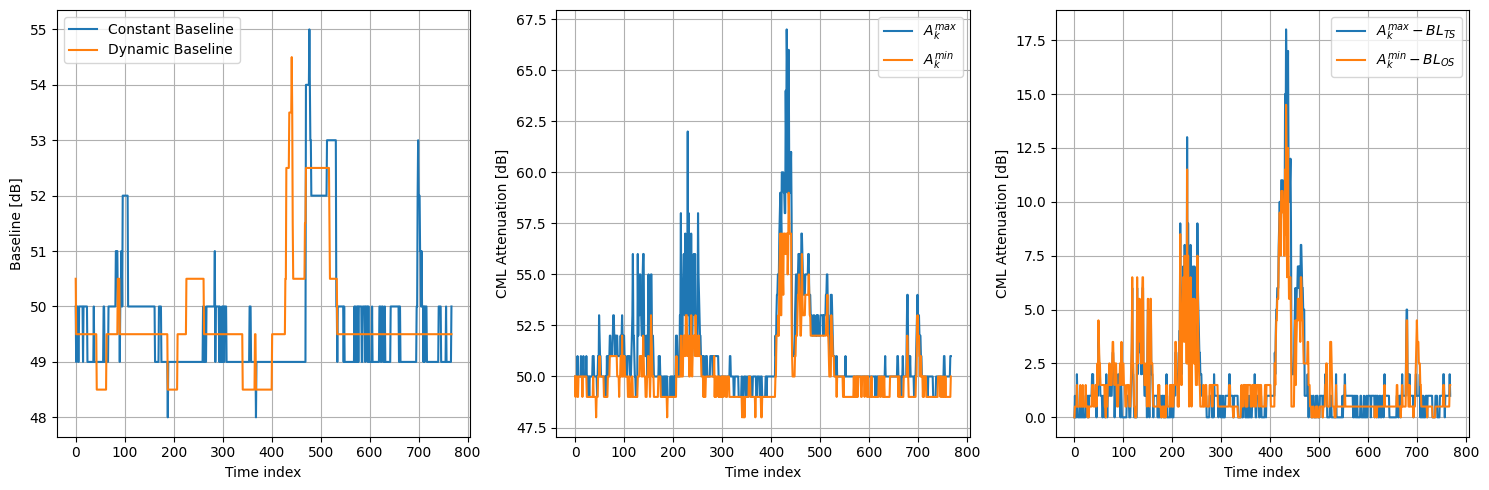

In [13]:
_, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(ts_baseline_res.numpy().flatten(), label="Constant Baseline")
axs[0].plot(os_baseline_res.numpy().flatten(), label="Dynamic Baseline")
axs[0].set_xlabel("Time index")
axs[0].set_ylabel("Baseline [dB]")
axs[0].grid()
axs[0].legend()

axs[1].plot(att[0,:,0].numpy().flatten(), label=r"$A_{k}^{max}$")
axs[1].plot(att[0,:,1].numpy().flatten(), label=r"$A_{k}^{min}$")
axs[1].set_xlabel("Time index")
axs[1].set_ylabel("CML Attenuation [dB]")
axs[1].grid()
axs[1].legend()

axs[2].plot(np.maximum(att[0,:,0].numpy().flatten()-ts_baseline_res.numpy().flatten(),0), label=r"$A_{k}^{max}-BL_{TS}$")
axs[2].plot(np.maximum(att[0,:,0].numpy().flatten()-os_baseline_res.numpy().flatten(),0), label=r"$A_{k}^{min}-BL_{OS}$")
axs[2].set_xlabel("Time index")
axs[2].set_ylabel("CML Attenuation [dB]")
axs[2].grid()
axs[2].legend()

plt.tight_layout()
plt.show()

Gauge ref resolutiopn from 5min per sample to 15min per sample:

Ref vs. Baseline for Link #0

In [15]:
ref_15min = gaugetime_5to15(linkmm)

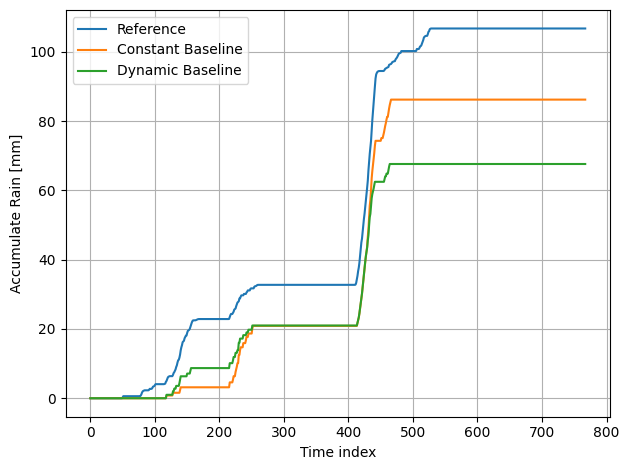

In [16]:
plt.plot(np.nancumsum(ref_15min), label="Reference")
plt.plot(np.cumsum(rain_ts), label="Constant Baseline")
plt.plot(np.cumsum(rain_os), label="Dynamic Baseline")
plt.xlabel("Time index")
plt.ylabel("Accumulate Rain [mm]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Ref vs. Constant Baseline of all high freq links

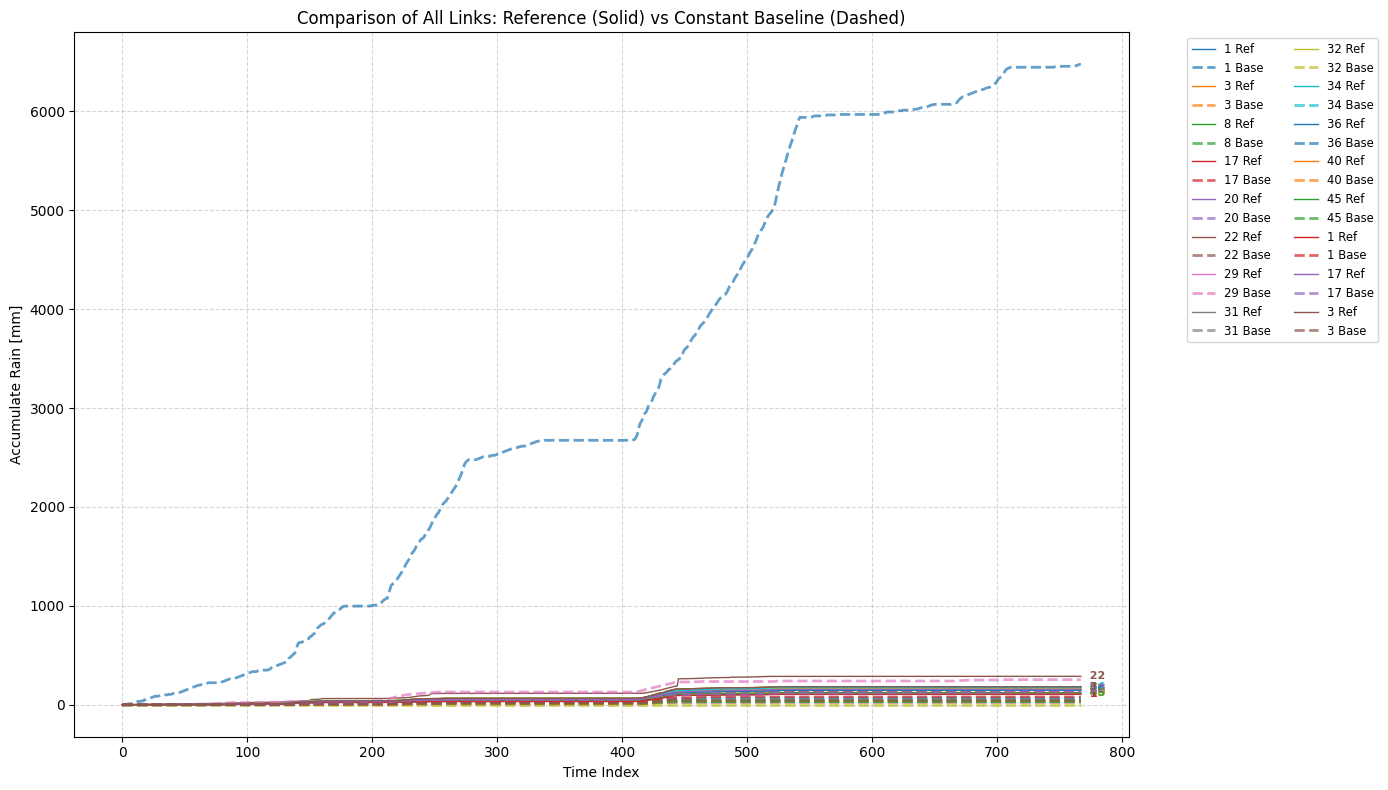

In [35]:
links = [i for i in range(0, len(HF_set))]

plt.figure(figsize=(14, 8))


for link_id in links:
    # 1. Get the data for this link
    ref_data = gaugetime_5to15(HF_set.get_link(link_id))
    rain_os, base_os = os_baseline(HF_set.get_link(link_id).attenuation(),
                                    HF_set.get_link(link_id).meta_data)
    
    # 2. Calculate cumulative sums
    cum_ref = np.nancumsum(ref_data)
    cum_base = np.nancumsum(rain_os)
    
    # 3. Plot both lines using the same color but different styles
    p = plt.plot(cum_ref, label=f"{HF_set.get_link(link_id).meta_data.cml_id} Ref", linestyle='-', linewidth=1)
    color = p[0].get_color() 
    plt.plot(cum_base, label=f"{HF_set.get_link(link_id).meta_data.cml_id} Base", linestyle='--', color=color, alpha=0.7, linewidth=2)

    # 4. Tag the lines for identification
    plt.text(len(cum_ref), cum_ref[-1], f"  {HF_set.get_link(link_id).meta_data.cml_id}", 
             color=color, va='center', fontsize=8, fontweight='bold')

plt.xlabel("Time Index")
plt.ylabel("Accumulate Rain [mm]")
plt.title("Comparison of All Links: Reference (Solid) vs Constant Baseline (Dashed)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

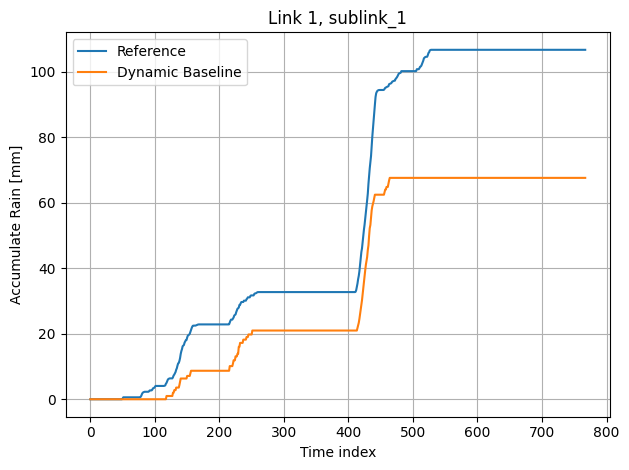

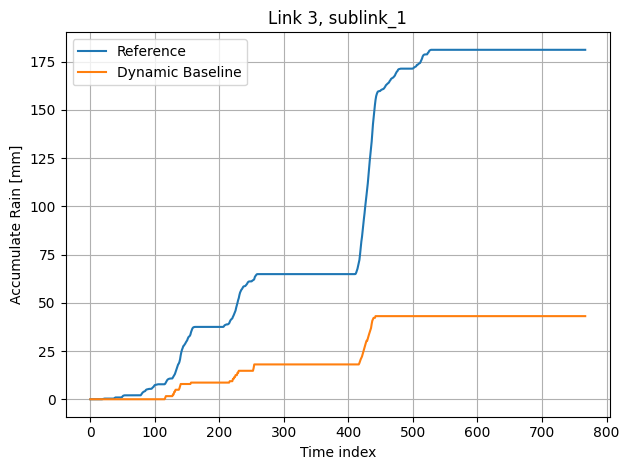

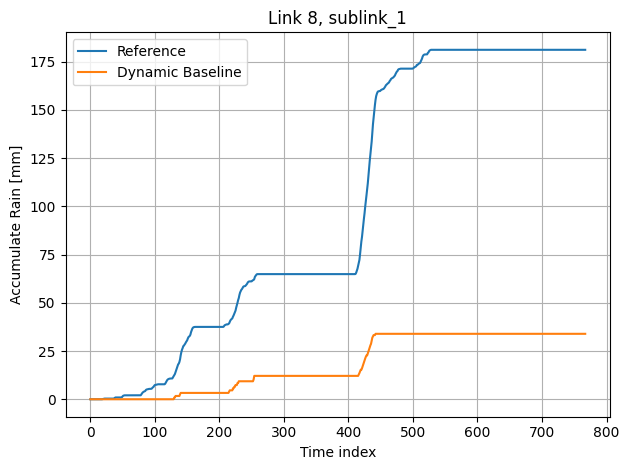

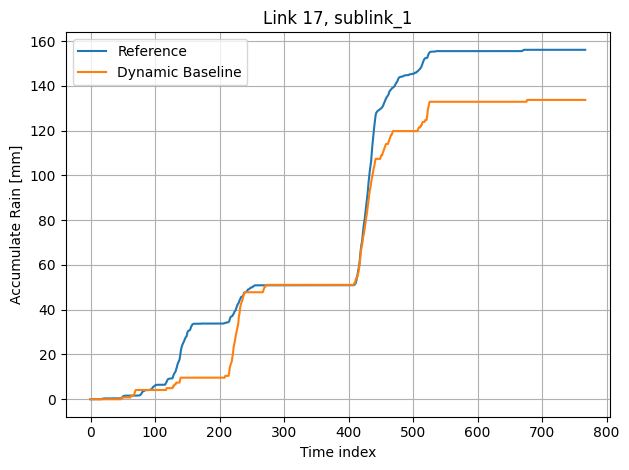

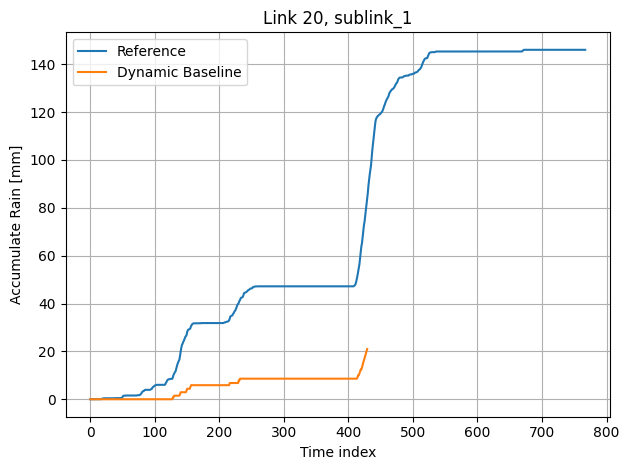

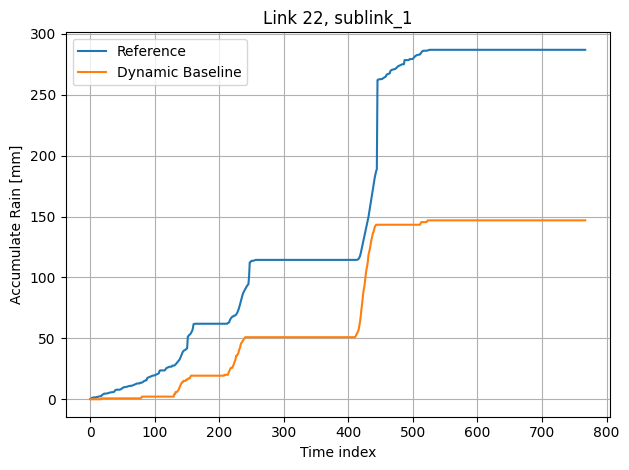

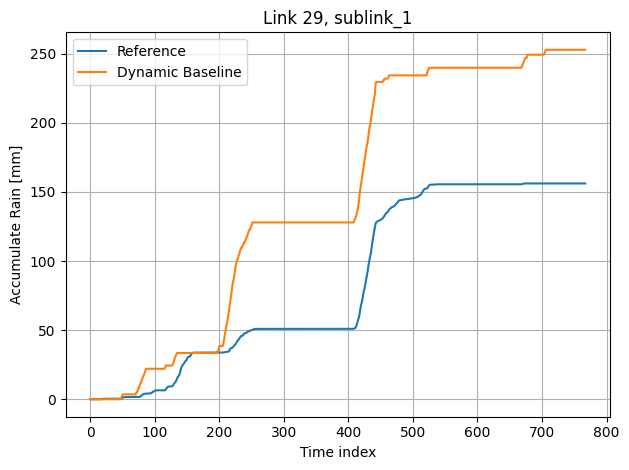

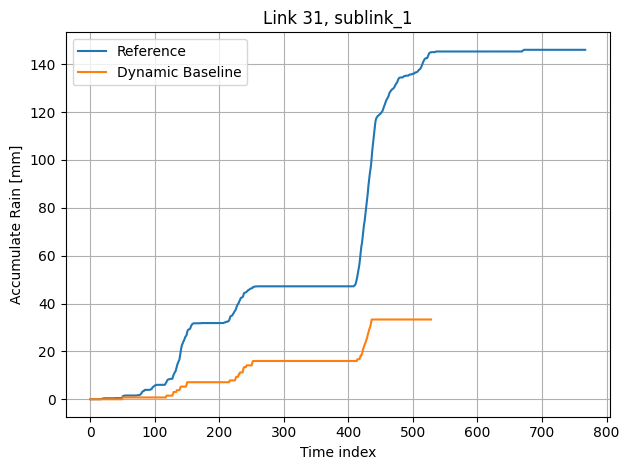

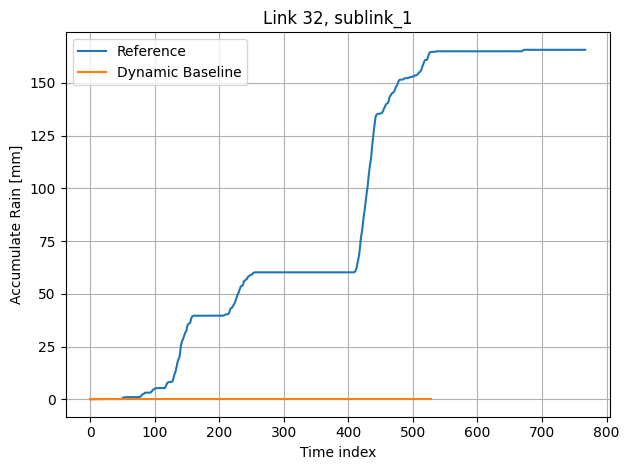

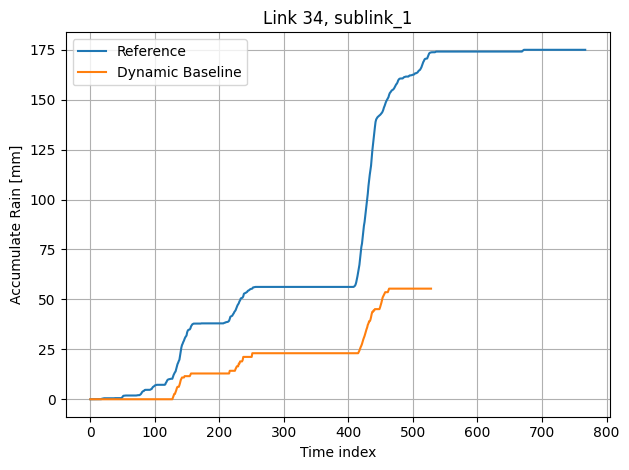

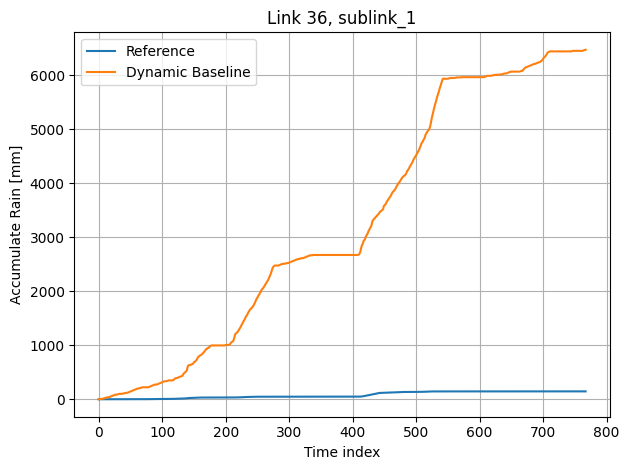

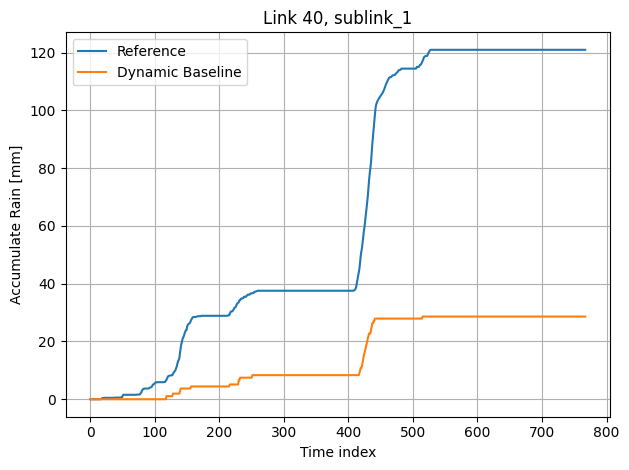

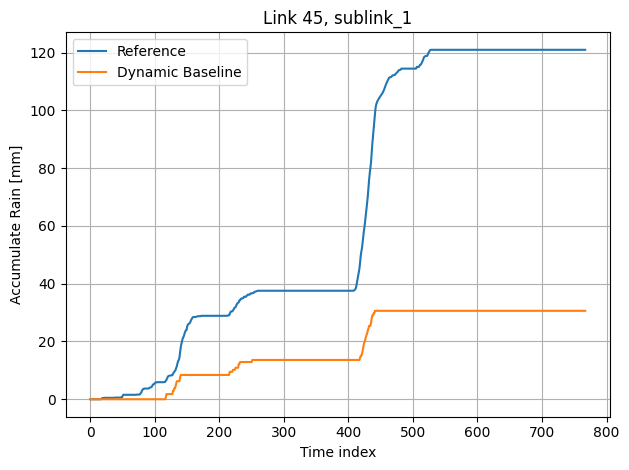

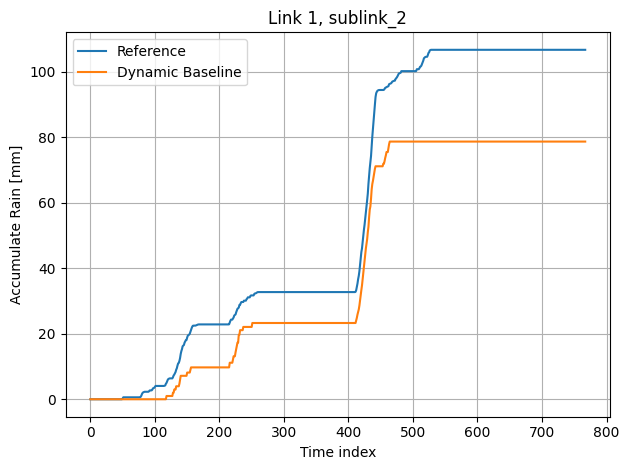

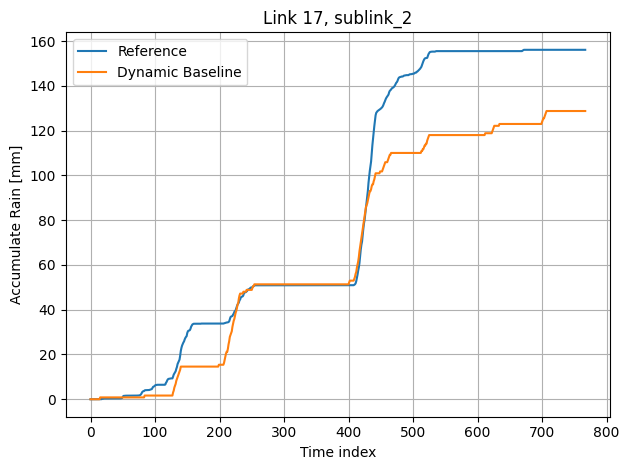

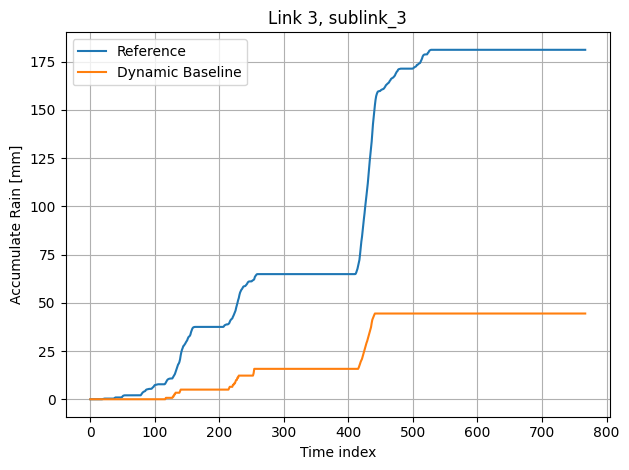

In [38]:
for link_id in links:
    ref_data = gaugetime_5to15(HF_set.get_link(link_id))
    rain_os, base_os = os_baseline(HF_set.get_link(link_id).attenuation(),
                                    HF_set.get_link(link_id).meta_data)
    plt.plot(np.nancumsum(ref_data), label="Reference")
    plt.plot(np.cumsum(rain_os), label="Dynamic Baseline")
    plt.title(f'Link {HF_set.get_link(link_id).meta_data.cml_id}, {HF_set.get_link(link_id).meta_data.sublink_id}')
    plt.xlabel("Time index")
    plt.ylabel("Accumulate Rain [mm]")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

Field Reconstruction

IDW

In [23]:
imc = pnc.mcm.InferMultipleCMLs(os_baseline)
res = imc(link_set)

NaN Tests:

In [43]:
import torch

# 1. Total number of elements
total = res.numel()

# 2. Count NaNs
n_nan = torch.isnan(res).sum().item()

# 3. Count Zeros
# Note: It's safer to use a small epsilon for floats, but usually 0. is exact in these outputs
n_zeros = (res == 0.0).sum().item()

# 4. Count "The Rest" (Actual Rain)
# These are values that are NOT nan and NOT zero
n_rain = total - n_nan - n_zeros

# Print the breakdown
print(f"Total entries: {total}")
print(f"NaNs (Missing/Error): {n_nan} ({100*n_nan/total:.2f}%)")
print(f"Zeros (Dry):         {n_zeros} ({100*n_zeros/total:.2f}%)")
print(f"Rain (Active):       {n_rain} ({100*n_rain/total:.2f}%)")

Total entries: 76800
NaNs (Missing/Error): 553 (0.72%)
Zeros (Dry):         30620 (39.87%)
Rain (Active):       45627 (59.41%)


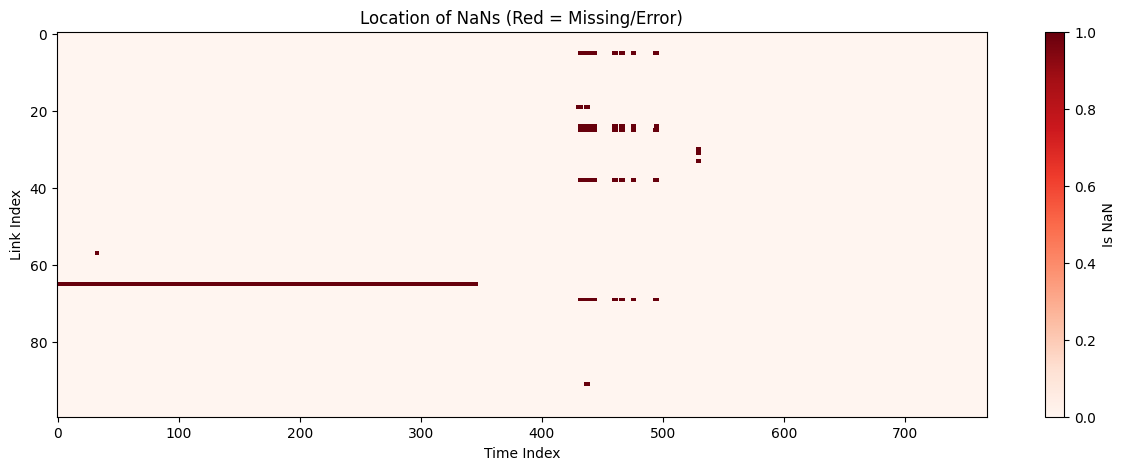

In [44]:
import matplotlib.pyplot as plt

# Create a binary mask: 1 for NaN, 0 for data
nan_mask = torch.isnan(res).float()

plt.figure(figsize=(15, 5))
# We use 'nearest' interpolation to see the individual gaps better
plt.imshow(nan_mask.cpu().numpy(), aspect='auto', cmap='Reds', interpolation='nearest')
plt.title("Location of NaNs (Red = Missing/Error)")
plt.xlabel("Time Index")
plt.ylabel("Link Index")
plt.colorbar(label="Is NaN")
plt.show()

In [45]:
# Calculate NaNs per row (per link)
nans_per_link = torch.isnan(res).sum(dim=1).float() / res.shape[1]

# Find links with more than 33% missing data
bad_links = torch.where(nans_per_link > 0.33)[0]
print(f"Number of links with >33% missing data: {len(bad_links)}")
print(f"Indices of worst links: {bad_links.tolist()[:10]}...")

Number of links with >33% missing data: 1
Indices of worst links: [65]...


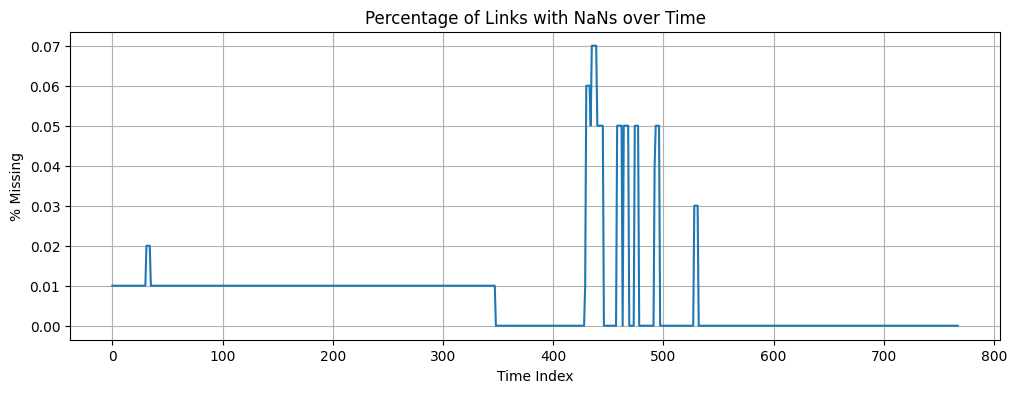

In [46]:
# Calculate NaNs per column (per time step)
nans_over_time = torch.isnan(res).sum(dim=0).float() / res.shape[0]

# Plot the timeline of missing data
plt.figure(figsize=(12, 4))
plt.plot(nans_over_time.cpu().numpy())
plt.title("Percentage of Links with NaNs over Time")
plt.ylabel("% Missing")
plt.xlabel("Time Index")
plt.grid(True)
plt.show()

In [94]:
# @title IDW Hyper-parameters
region_of_interest = 2  # @param{"type": "integer"}

In [95]:
idw = pnc.mcm.generate_link_set_idw(link_set, roi=region_of_interest)
rain_map = idw(res).numpy()

GMZ

In [96]:
# @title GMZ Hyper-parameters
point_per_link = 2  # @param{"type": "integer"}

In [97]:
gmz = pnc.mcm.generate_link_set_gmz(link_set, roi=region_of_interest, point_per_link=point_per_link)
rain_map_gmz, losses = gmz(res)
rain_map_gmz = rain_map_gmz.numpy()

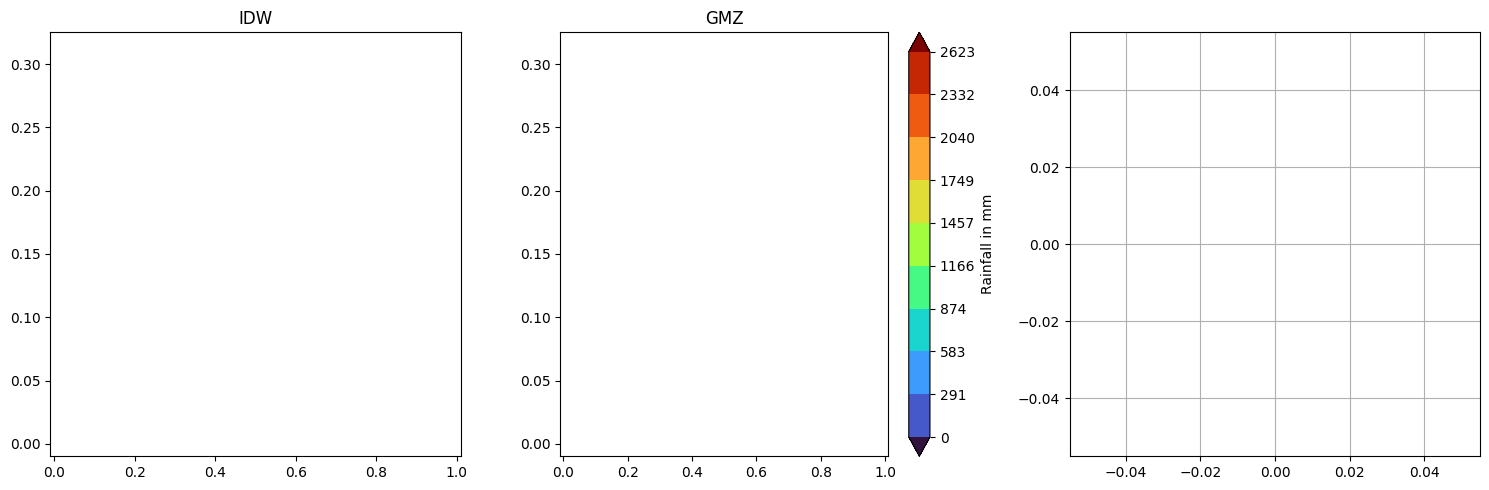

In [98]:
index = np.argmax(np.std(rain_map, axis=(1, 2)))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
peak_rain = np.max([np.nanmax(rain_map), np.nanmax(rain_map_gmz)])
bounds = np.arange(0, peak_rain, peak_rain / 10)
# bounds[0] = 1

norm = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='both')

pc_zero = ax[0].pcolormesh(
    idw.x_grid_vector,
    idw.y_grid_vector,
    rain_map[index, :, :].T,
    shading='nearest',
    cmap='turbo',
    norm=norm,
)
ax[0].set_title('IDW')
pc_one = ax[1].pcolormesh(
    idw.x_grid_vector,
    idw.y_grid_vector,
    rain_map_gmz[index, :, :].T,
    shading='nearest',
    cmap='turbo',
    norm=norm,
)
ax[1].set_title('GMZ')

ax[2].plot(losses[:, index])
ax[2].grid()
fig.colorbar(pc_one, label='Rainfall in mm')
plt.tight_layout()
plt.show()
